In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from fg_model import *
from SEDfitting import *
from scipy.interpolate import RegularGridInterpolator

In [ ]:
filepath="../MERS/data/"

### Generate foregrounds
(Using Mel's model)

In [6]:
freq_list = np.arange(50.0, 200.0+0.5, 0.5)

# Generate the beam convolved Mel maps
Mel_model = SynchrotronExtrapolator()
mel_sky = Mel_model.map(freq_list)#, beam_window)


### Timestream of the zenith  
LSTs → (RA, Dec) → Galactic (l, b) → HEALPix pixel index

In [9]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
nside = 512  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(nside, vecs[0], vecs[1], vecs[2])

# === Example output ===
for time, lst, pix in zip(times[:5], lst_array[:5], pix_indices[:5]):
    print(f"UTC: {time.iso} | LST: {lst.to_string(unit=u.hour)} | HEALPix pixel: {pix}")


UTC: 2024-10-01 22:00:00.000 | LST: 22h35m15.91468459s | HEALPix pixel: 1691211
UTC: 2024-10-01 22:02:00.000 | LST: 22h37m16.24323363s | HEALPix pixel: 1697357
UTC: 2024-10-01 22:04:00.000 | LST: 22h39m16.57178268s | HEALPix pixel: 1699406
UTC: 2024-10-01 22:06:00.000 | LST: 22h41m16.90033172s | HEALPix pixel: 1705552
UTC: 2024-10-01 22:08:00.000 | LST: 22h43m17.22888076s | HEALPix pixel: 1707601


### Generate RHINO timestream of data (foreground components only)
shape: (n_LST, n_freqs)

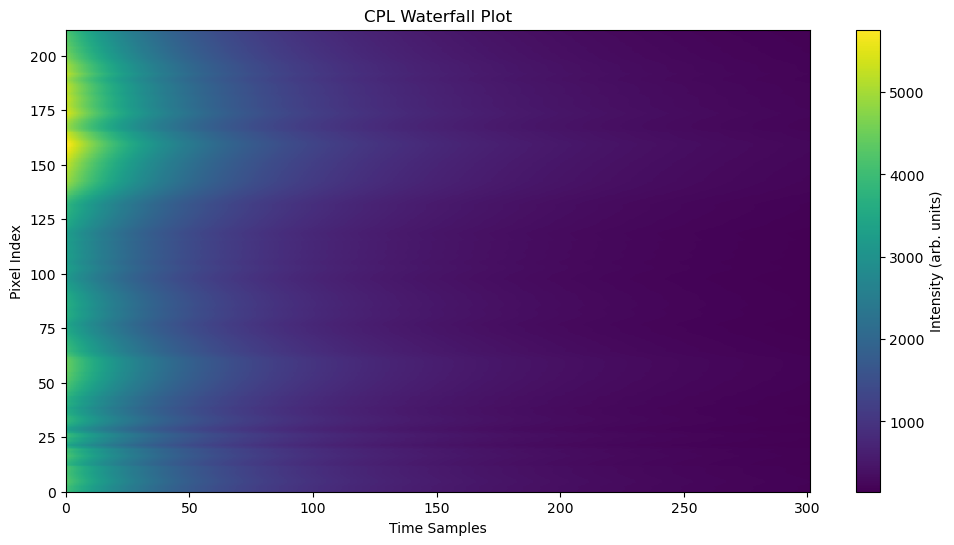

In [12]:
melsky_tod = mel_sky[pix_indices, :]
spec_ind_tod = Mel_model.specidx_map[pix_indices]

# Present the waterfall of the RHINO_tod
plt.figure(figsize=(12, 6))
plt.imshow(melsky_tod, aspect='auto', origin='lower', 
           extent=[0, melsky_tod.shape[1], 0, melsky_tod.shape[0]])
plt.xlabel('Time Samples')
plt.ylabel('Pixel Index')
plt.colorbar(label='Intensity (arb. units)')
plt.title('CPL Waterfall Plot')
plt.show()

### Fitting RHINO TOD (foregrounds components)

In [15]:
coeffs_tod_fixed, loss_tod_fixed = fit_entire_fg_map(melsky_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_tod_adapted, loss_tod_adapted = fit_entire_fg_map(melsky_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

Processing pixels:  67%|███████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                   | 142/212 [00:00<00:00, 330.99it/s]/Users/bellanasirudin/Software/MERS/SEDfitting.py:211: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2582: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/bellanasirudin/Software/MERS/SEDfitting.py:218: RuntimeWarning: invalid value encountered in divide
  result /= norms[np.newaxis, :]  # Normalize each column by its l2-norm


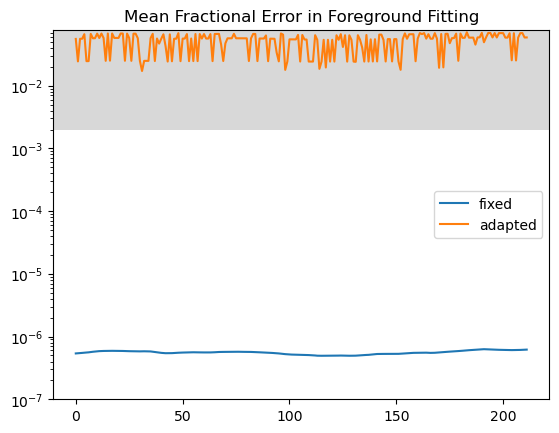

In [17]:
plt.plot(loss_tod_fixed, label='fixed')
plt.plot(loss_tod_adapted, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()

In [19]:
# Average neighbor 10 LSTs in RHINO_tod:
window_size = 41  # -5 to +5 inclusive (11 elements total)
windows = np.lib.stride_tricks.sliding_window_view(melsky_tod, (window_size,), axis=0)
melsky_tod_rolling_average = windows.mean(axis=-1)

In [21]:
coeffs_roll_avrg_tod_fixed, loss_roll_avrg_tod_fixed = fit_entire_fg_map(melsky_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_roll_avrg_tod_adapted, loss_roll_avrg_tod_adapted = fit_entire_fg_map(melsky_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

Processing pixels:   0%|                                                                                                                                                                      | 0/172 [00:00<?, ?it/s]/Users/bellanasirudin/Software/MERS/SEDfitting.py:211: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2582: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/bellanasirudin/Software/MERS/SEDfitting.py:218: RuntimeWarning: invalid value encountered in divide
  result /= norms[np.newaxis, :]  # Normalize each column by its l2-norm


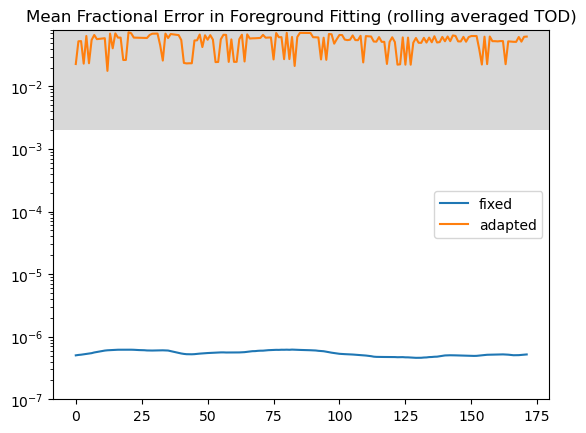

In [23]:
plt.plot(loss_roll_avrg_tod_fixed, label='fixed')
plt.plot(loss_roll_avrg_tod_adapted, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting (rolling averaged TOD)')
plt.legend()

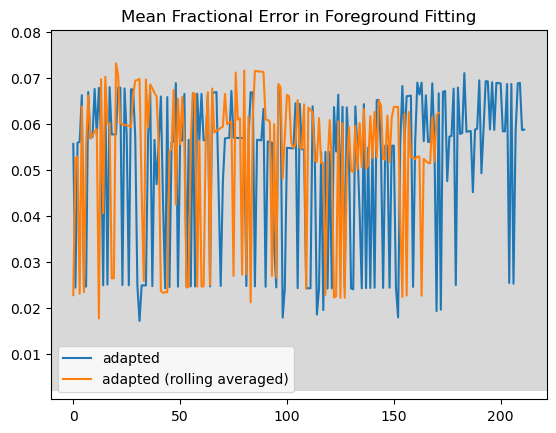

In [25]:
plt.plot(loss_tod_adapted, label='adapted')
plt.plot(loss_roll_avrg_tod_adapted, label='adapted (rolling averaged)')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(0.0001, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()

## Adding Point Sources with Fixed Beta

In [28]:
psfg = np.load(filepath + "gleam_nside512_K_allsky_50MHz.npy")
beta_psfg = -2.3

mel_psrc_sky = mel_sky + np.outer(psfg, (freq_list/50)**beta_psfg)

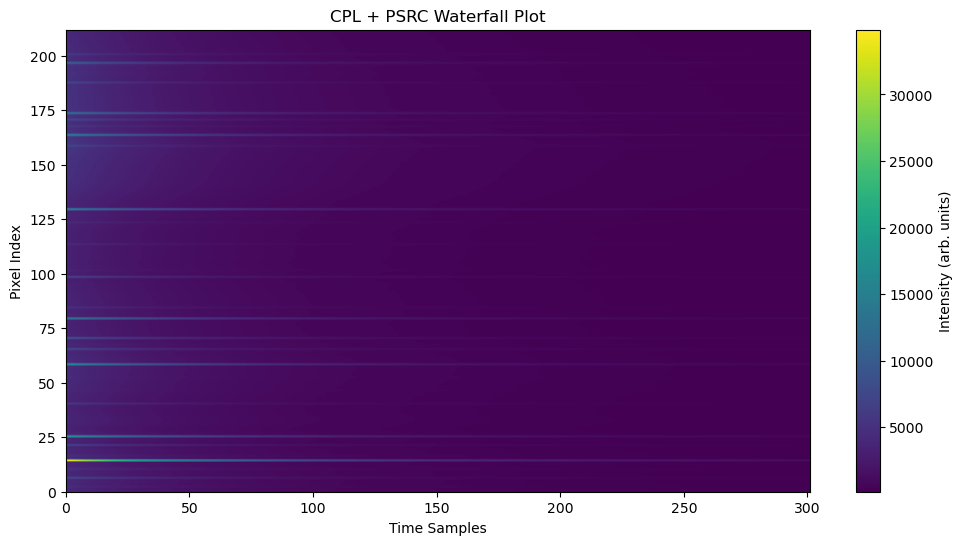

In [29]:
melsky_psrc_tod = mel_psrc_sky[pix_indices, :]
spec_ind_tod = Mel_model.specidx_map[pix_indices]

# Present the waterfall of the RHINO_tod
plt.figure(figsize=(12, 6))
plt.imshow(melsky_psrc_tod, aspect='auto', origin='lower', 
           extent=[0, melsky_tod.shape[1], 0, melsky_tod.shape[0]])
plt.xlabel('Time Samples')
plt.ylabel('Pixel Index')
plt.colorbar(label='Intensity (arb. units)')
plt.title('CPL + PSRC Waterfall Plot')
plt.show()

In [32]:
coeffs_tod_fixed_ps, loss_tod_fixed_ps = fit_entire_fg_map(melsky_psrc_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_tod_adapted_ps, loss_tod_adapted_ps = fit_entire_fg_map(melsky_psrc_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

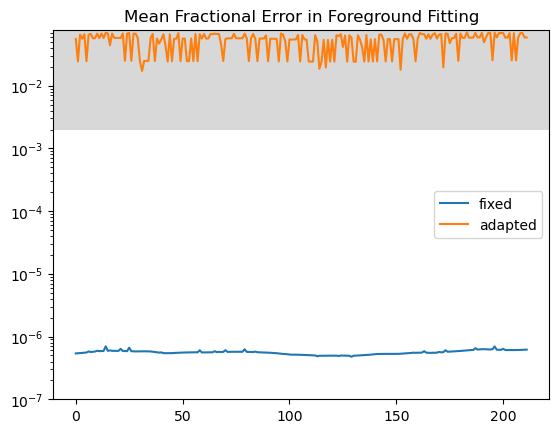

In [34]:
plt.plot(loss_tod_fixed_ps, label='fixed')
plt.plot(loss_tod_adapted_ps, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()

In [36]:
window_size = 41  # -5 to +5 inclusive (11 elements total)
windows = np.lib.stride_tricks.sliding_window_view(melsky_psrc_tod, (window_size,), axis=0)
melsky_psrc_tod_rolling_average = windows.mean(axis=-1)

In [38]:
coeffs_roll_avrg_tod_fixed, loss_roll_avrg_tod_fixed_ps = fit_entire_fg_map(melsky_psrc_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_roll_avrg_tod_adapted, loss_roll_avrg_tod_adapted_ps = fit_entire_fg_map(melsky_psrc_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

                                                                                                                                                                                                                      /Users/bellanasirudin/Software/MERS/SEDfitting.py:211: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2582: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/bellanasirudin/Software/MERS/SEDfitting.py:218: RuntimeWarning: invalid value encountered in divide
  result /= norms[np.newaxis, :]  # Normalize each column by its l2-norm


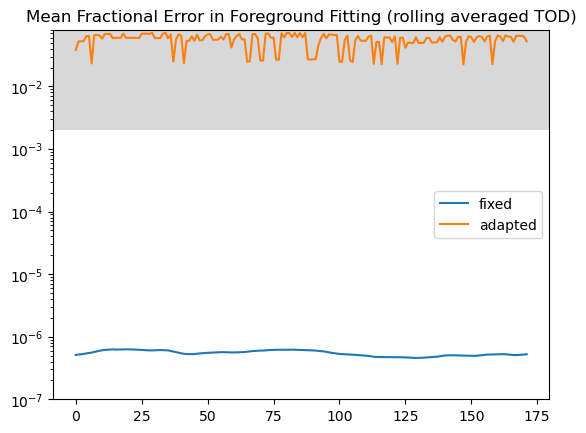

In [40]:
plt.plot(loss_roll_avrg_tod_fixed_ps, label='fixed')
plt.plot(loss_roll_avrg_tod_adapted_ps, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting (rolling averaged TOD)')
plt.legend()

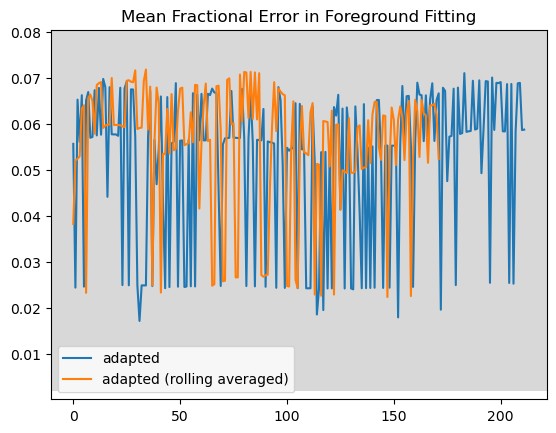

In [42]:
plt.plot(loss_tod_adapted_ps, label='adapted')
plt.plot(loss_roll_avrg_tod_adapted_ps, label='adapted (rolling averaged)')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(0.0001, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()

## Adding Point Sources with Varying Beta

In [45]:
data = np.load(filepath + "gleam_nside512_K_allsky_50MHz_16freqs.npz")
freqs = data["freqs"]
psfg = data["psrc_sky"]

# need to interpolate the frequencies
interp = RegularGridInterpolator((freqs, np.arange(np.shape(psfg)[-1])), psfg)

X, Y = np.meshgrid(freq_list, np.arange(np.shape(psfg)[-1]))
mel_psrc_sky_beta = mel_sky + interp((X, Y))

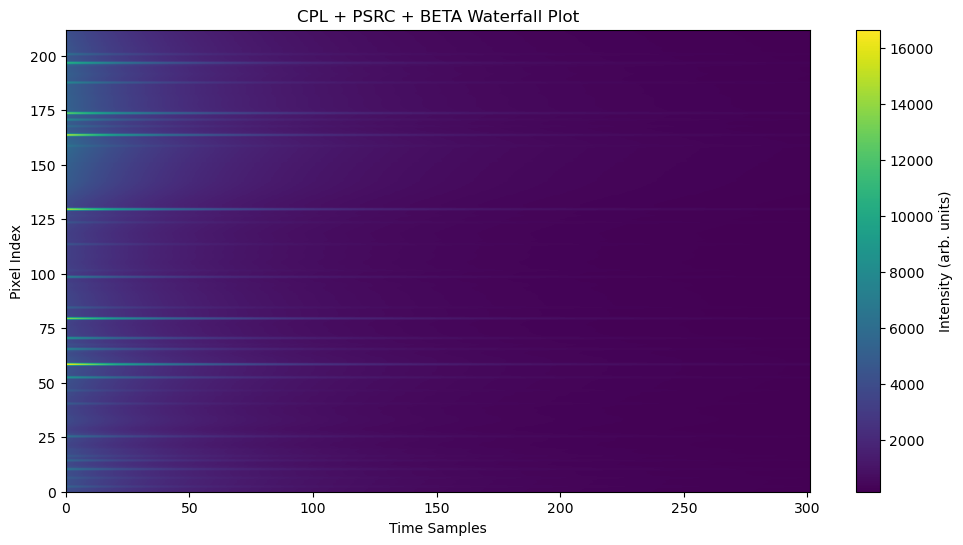

In [46]:
melsky_psrc_beta_tod = mel_psrc_sky_beta[pix_indices, :]
# spec_ind_tod = Mel_model.specidx_map[pix_indices]

# Present the waterfall of the RHINO_tod
plt.figure(figsize=(12, 6))
plt.imshow(melsky_psrc_beta_tod, aspect='auto', origin='lower', 
           extent=[0, melsky_tod.shape[1], 0, melsky_tod.shape[0]])
plt.xlabel('Time Samples')
plt.ylabel('Pixel Index')
plt.colorbar(label='Intensity (arb. units)')
plt.title('CPL + PSRC + BETA Waterfall Plot')
plt.show()

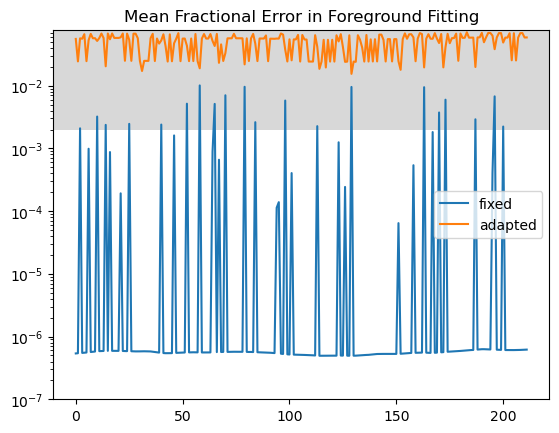

In [47]:
coeffs_tod_fixed_ps_beta, loss_tod_fixed_ps_beta = fit_entire_fg_map(melsky_psrc_beta_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_tod_adapted_ps_beta, loss_tod_adapted_ps_beta = fit_entire_fg_map(melsky_psrc_beta_tod, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

plt.plot(loss_tod_fixed_ps_beta, label='fixed')
plt.plot(loss_tod_adapted_ps_beta, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()

In [48]:
window_size = 41  # -5 to +5 inclusive (11 elements total)
windows = np.lib.stride_tricks.sliding_window_view(melsky_psrc_beta_tod, (window_size,), axis=0)
melsky_psrc_beta_tod_rolling_average = windows.mean(axis=-1)

coeffs_roll_avrg_tod_fixed, loss_roll_avrg_tod_fixed_ps_beta = fit_entire_fg_map(melsky_psrc_beta_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=True)
coeffs_roll_avrg_tod_adapted, loss_roll_avrg_tod_adapted_ps_beta = fit_entire_fg_map(melsky_psrc_beta_tod_rolling_average, spec_ind_tod, freq_list, nu_ref=None, max_order=6, fixed_pivot=False)

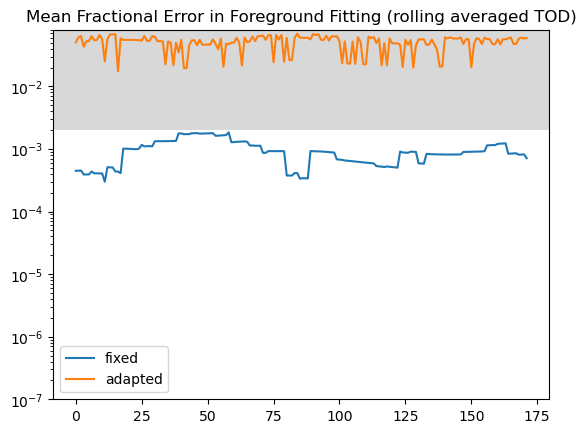

In [49]:
plt.plot(loss_roll_avrg_tod_fixed_ps_beta, label='fixed')
plt.plot(loss_roll_avrg_tod_adapted_ps_beta, label='adapted')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(1e-7, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.yscale('log')
plt.title('Mean Fractional Error in Foreground Fitting (rolling averaged TOD)')
plt.legend()

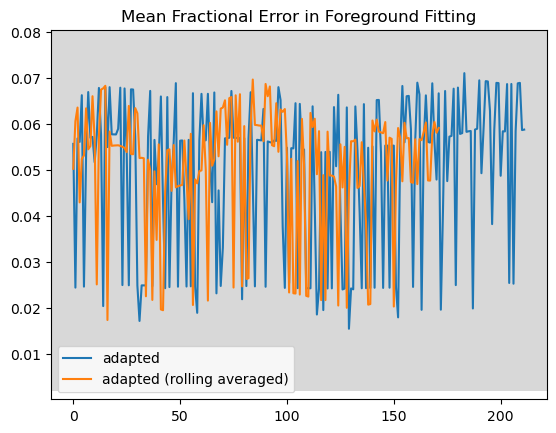

In [50]:
plt.plot(loss_tod_adapted_ps_beta, label='adapted')
plt.plot(loss_roll_avrg_tod_adapted_ps_beta, label='adapted (rolling averaged)')
# Set the region above 0.002 to be gray
plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
plt.ylim(0.0001, 1.1*np.max(loss_roll_avrg_tod_adapted))
plt.title('Mean Fractional Error in Foreground Fitting')
plt.legend()